<h1 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     Credit Card Clients
</h1>


<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     IMPORT LIBRARIES
</h2>


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve,auc,classification_report,confusion_matrix

from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

import streamlit as st
import pickle

<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     LOADING DATASET
</h2>


In [2]:
df=pd.read_csv(r"C:\Users\tatak\haroon\DATASETS\credit_card_clients.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,PAY_AMT1,PAY_AMT2,PAY_AMT3,default payment next month
0,1,20000,Female,University,Married,24,2,2,-1,3913,3102,0,689,0,1
1,2,120000,Female,University,Single,26,-1,2,0,2682,1725,0,1000,1000,1
2,3,90000,Female,University,Single,34,0,0,0,29239,14027,1518,1500,1000,0
3,4,50000,Female,University,Married,37,0,0,0,46990,48233,2000,2019,1200,0
4,5,50000,Male,University,Married,57,-1,0,-1,8617,5670,2000,36681,10000,0


In [3]:
df.drop(["ID"],axis=1,inplace=True)

<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     CHECKING SHAPE AND COLUMN
</h2>


In [4]:
df.shape

(5000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   LIMIT_BAL                   5000 non-null   int64 
 1   SEX                         5000 non-null   object
 2   EDUCATION                   5000 non-null   object
 3   MARRIAGE                    5000 non-null   object
 4   AGE                         5000 non-null   int64 
 5   PAY_0                       5000 non-null   int64 
 6   PAY_2                       5000 non-null   int64 
 7   PAY_3                       5000 non-null   int64 
 8   BILL_AMT1                   5000 non-null   int64 
 9   BILL_AMT2                   5000 non-null   int64 
 10  PAY_AMT1                    5000 non-null   int64 
 11  PAY_AMT2                    5000 non-null   int64 
 12  PAY_AMT3                    5000 non-null   int64 
 13  default payment next month  5000 non-null   int6

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,5000.0,165640.0000,130339.357332,10000.0,50000.00,140000.0,230000.00,1000000.0
AGE,5000.0,35.3698,9.267698,21.0,28.00,34.0,41.00,75.0
PAY_0,5000.0,0.0050,1.131208,-2.0,-1.00,0.0,0.00,8.0
PAY_2,5000.0,-0.1484,1.204603,-2.0,-1.00,0.0,0.00,7.0
PAY_3,5000.0,-0.1594,1.220283,-2.0,-1.00,0.0,0.00,7.0
BILL_AMT1,5000.0,50216.1562,74839.564927,-14386.0,3207.50,21321.0,62633.50,964511.0
BILL_AMT2,5000.0,48280.4864,72320.271359,-30000.0,2941.25,20578.5,60543.25,983931.0
PAY_AMT1,5000.0,5576.7506,14853.733073,0.0,1000.00,2113.0,5001.00,368199.0
PAY_AMT2,5000.0,5431.2652,16280.701542,0.0,639.50,2000.0,5000.00,344261.0
PAY_AMT3,5000.0,4604.0426,18006.348435,0.0,222.75,1403.0,4000.00,896040.0


<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     Missing Values Detection and Outlier Handling
</h2>


In [7]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
BILL_AMT1                     0
BILL_AMT2                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
default payment next month    0
dtype: int64

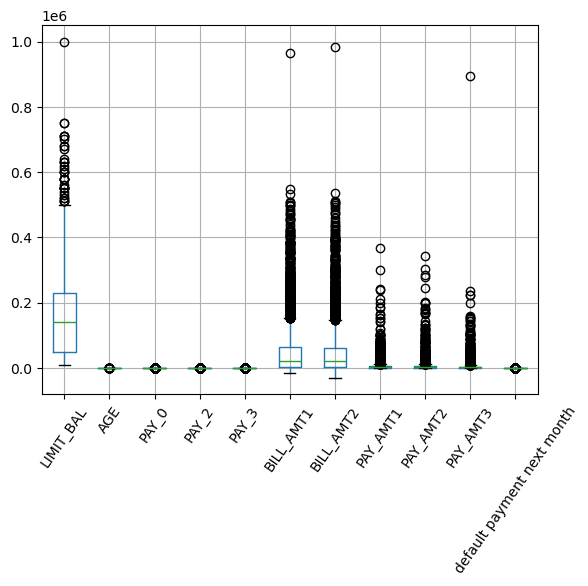

In [8]:
df.boxplot()
plt.xticks(rotation=55)
plt.show()

In [9]:
df1=['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'BILL_AMT1',
       'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

In [10]:
for i in df1:
    Q1=df[i].quantile(.25)
    Q3=df[i].quantile(.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    df[i]=df[i].clip(lower_limit,upper_limit)

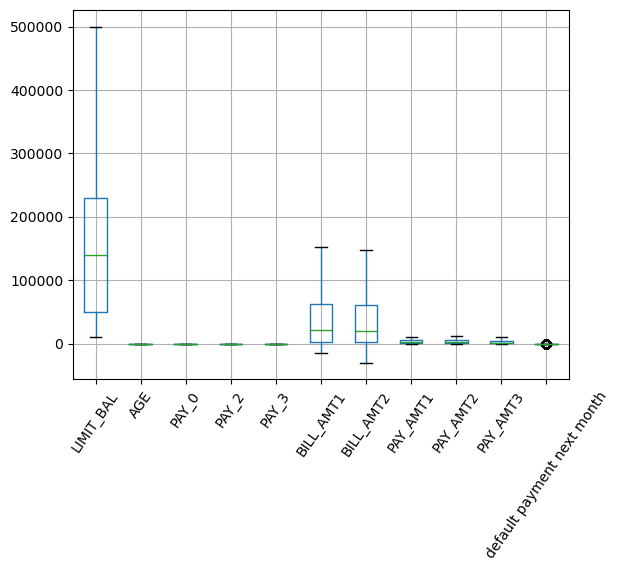

In [11]:
df.boxplot()
plt.xticks(rotation=55)
plt.show()

In [12]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,PAY_AMT1,PAY_AMT2,PAY_AMT3,default payment next month
0,20000,Female,University,Married,24.0,1.5,1.5,-1.0,3913.0,3102.00,0.0,689.00,0.000,1
1,120000,Female,University,Single,26.0,-1.0,1.5,0.0,2682.0,1725.00,0.0,1000.00,1000.000,1
2,90000,Female,University,Single,34.0,0.0,0.0,0.0,29239.0,14027.00,1518.0,1500.00,1000.000,0
3,50000,Female,University,Married,37.0,0.0,0.0,0.0,46990.0,48233.00,2000.0,2019.00,1200.000,0
4,50000,Male,University,Married,57.0,-1.0,0.0,-1.0,8617.0,5670.00,2000.0,11540.75,9665.875,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,20000,Female,University,Married,36.0,0.0,0.0,0.0,16320.0,18044.00,2000.0,1283.00,1003.000,0
4996,180000,Female,Other,Married,34.0,-1.0,-1.0,-1.0,6892.0,6892.00,6892.0,6892.00,6282.000,0
4997,200000,Female,University,Married,45.0,0.0,0.0,0.0,151772.5,121830.00,4543.0,5000.00,4500.000,1
4998,310000,Male,High_School,Married,44.0,0.0,0.0,0.0,151772.5,146946.25,10000.0,10000.00,9665.875,0


<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     EDA
</h2>


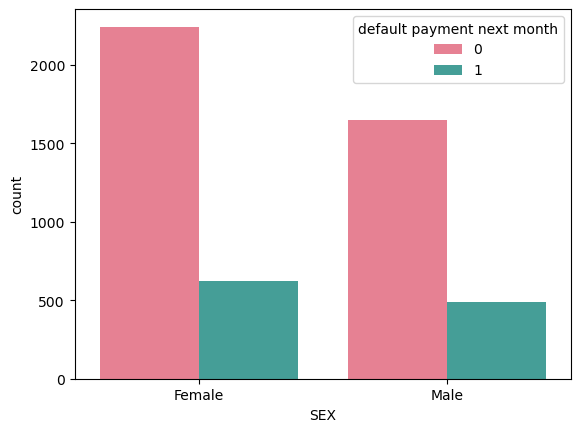

In [13]:
sns.countplot(x="SEX",hue="default payment next month",data=df,palette="husl")
plt.show()

Default rates are similar for males and females, so gender has little impact on default risk


In [14]:
df2=df.select_dtypes(include='number')

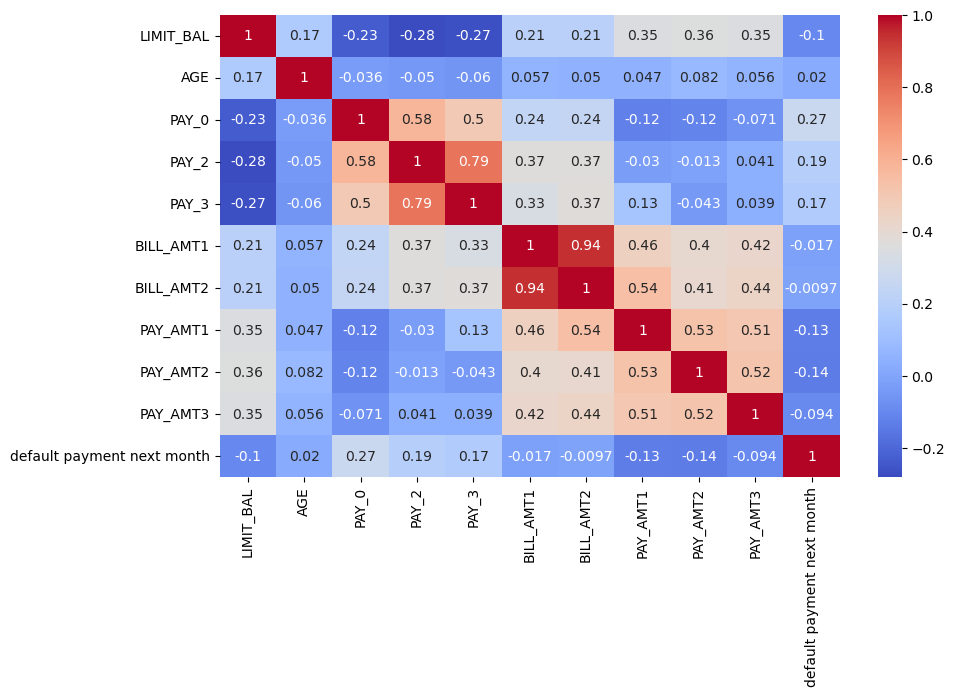

In [15]:
plt.figure(figsize=(10,6))
df3=df2.corr()
sns.heatmap(df3,annot=True,cmap="coolwarm")
plt.show()

Default risk is strongly linked to recent payment delays, while higher repayments and credit limits slightly reduce the chance of default.


<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     ENCODING
</h2>


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le=LabelEncoder()
for i in ["SEX","EDUCATION","MARRIAGE"]:
    df[i]=le.fit_transform(df[i])
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,PAY_AMT1,PAY_AMT2,PAY_AMT3,default payment next month
0,20000,0,3,0,24.0,1.5,1.5,-1.0,3913.0,3102.00,0.0,689.00,0.000,1
1,120000,0,3,1,26.0,-1.0,1.5,0.0,2682.0,1725.00,0.0,1000.00,1000.000,1
2,90000,0,3,1,34.0,0.0,0.0,0.0,29239.0,14027.00,1518.0,1500.00,1000.000,0
3,50000,0,3,0,37.0,0.0,0.0,0.0,46990.0,48233.00,2000.0,2019.00,1200.000,0
4,50000,1,3,0,57.0,-1.0,0.0,-1.0,8617.0,5670.00,2000.0,11540.75,9665.875,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,20000,0,3,0,36.0,0.0,0.0,0.0,16320.0,18044.00,2000.0,1283.00,1003.000,0
4996,180000,0,2,0,34.0,-1.0,-1.0,-1.0,6892.0,6892.00,6892.0,6892.00,6282.000,0
4997,200000,0,3,0,45.0,0.0,0.0,0.0,151772.5,121830.00,4543.0,5000.00,4500.000,1
4998,310000,1,1,0,44.0,0.0,0.0,0.0,151772.5,146946.25,10000.0,10000.00,9665.875,0


In [18]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'default payment next month'],
      dtype='object')

<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     SCALING
</h2>


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler=StandardScaler()
cols=['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3']
sca=scaler.fit_transform(df[cols])
sca

array([[-1.13582159, -0.86360295,  1.05641584, ..., -0.9958125 ,
        -0.72809963, -0.86250543],
       [-0.35133857, -0.86360295,  1.05641584, ..., -0.9958125 ,
        -0.64036926, -0.53751652],
       [-0.58668348, -0.86360295,  1.05641584, ..., -0.56304674,
        -0.49932365, -0.53751652],
       ...,
       [ 0.27624785, -0.86360295,  1.05641584, ...,  0.29934877,
         0.4879956 ,  0.59994466],
       [ 1.13917918,  1.15793954, -0.39450552, ...,  1.85508178,
         1.89845169,  2.27879675],
       [-0.03754536,  1.15793954, -1.1199662 , ..., -0.9958125 ,
        -0.72076526, -0.63013836]], shape=(5000, 13))

In [21]:
df[['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3']]=pd.DataFrame(sca,columns=cols)
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,PAY_AMT1,PAY_AMT2,PAY_AMT3,default payment next month
0,-1.135822,-0.863603,1.056416,-1.121765,-1.238541,1.687778,1.778030,-0.746931,-0.786814,-0.799326,-0.995812,-0.728100,-0.862505,1
1,-0.351339,-0.863603,1.056416,0.891453,-1.019955,-0.990895,1.778030,0.262708,-0.812180,-0.828739,-0.995812,-0.640369,-0.537517,1
2,-0.586683,-0.863603,1.056416,0.891453,-0.145611,0.080574,0.252173,0.262708,-0.264936,-0.565959,-0.563047,-0.499324,-0.537517,0
3,-0.900477,-0.863603,1.056416,-1.121765,0.182268,0.080574,0.252173,0.262708,0.100848,0.164709,-0.425634,-0.352918,-0.472519,0
4,-0.900477,1.157940,1.056416,-1.121765,2.368128,-0.990895,0.252173,-0.746931,-0.689882,-0.744471,-0.425634,2.333084,2.278797,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.135822,-0.863603,1.056416,-1.121765,0.072975,0.080574,0.252173,0.262708,-0.531150,-0.480152,-0.425634,-0.560537,-0.536542,0
4996,0.119351,-0.863603,0.330955,-1.121765,-0.145611,-0.990895,-0.765065,-0.746931,-0.725428,-0.718368,0.969024,1.021712,1.179075,0
4997,0.276248,-0.863603,1.056416,-1.121765,1.056612,0.080574,0.252173,0.262708,2.260037,1.736800,0.299349,0.487996,0.599945,1
4998,1.139179,1.157940,-0.394506,-1.121765,0.947319,0.080574,0.252173,0.262708,2.260037,2.273303,1.855082,1.898452,2.278797,0


<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     MODEL SPLITING AND TRANING
</h2>


In [22]:
x=df.drop(["default payment next month"],axis=1)
x

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,PAY_AMT1,PAY_AMT2,PAY_AMT3
0,-1.135822,-0.863603,1.056416,-1.121765,-1.238541,1.687778,1.778030,-0.746931,-0.786814,-0.799326,-0.995812,-0.728100,-0.862505
1,-0.351339,-0.863603,1.056416,0.891453,-1.019955,-0.990895,1.778030,0.262708,-0.812180,-0.828739,-0.995812,-0.640369,-0.537517
2,-0.586683,-0.863603,1.056416,0.891453,-0.145611,0.080574,0.252173,0.262708,-0.264936,-0.565959,-0.563047,-0.499324,-0.537517
3,-0.900477,-0.863603,1.056416,-1.121765,0.182268,0.080574,0.252173,0.262708,0.100848,0.164709,-0.425634,-0.352918,-0.472519
4,-0.900477,1.157940,1.056416,-1.121765,2.368128,-0.990895,0.252173,-0.746931,-0.689882,-0.744471,-0.425634,2.333084,2.278797
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.135822,-0.863603,1.056416,-1.121765,0.072975,0.080574,0.252173,0.262708,-0.531150,-0.480152,-0.425634,-0.560537,-0.536542
4996,0.119351,-0.863603,0.330955,-1.121765,-0.145611,-0.990895,-0.765065,-0.746931,-0.725428,-0.718368,0.969024,1.021712,1.179075
4997,0.276248,-0.863603,1.056416,-1.121765,1.056612,0.080574,0.252173,0.262708,2.260037,1.736800,0.299349,0.487996,0.599945
4998,1.139179,1.157940,-0.394506,-1.121765,0.947319,0.080574,0.252173,0.262708,2.260037,2.273303,1.855082,1.898452,2.278797


In [23]:
y=df["default payment next month"]
y

0       1
1       1
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    1
4998    0
4999    0
Name: default payment next month, Length: 5000, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=43)

<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     MODEL FITING
</h2>


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score

In [27]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [28]:
y_predlr=lr.predict(x_test)
y_predlr

array([1, 0, 0, ..., 0, 0, 0], shape=(1500,))

In [29]:
accuracylr=accuracy_score(y_test,y_predlr)
accuracylr

0.7893333333333333

In [30]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [31]:
y_predrf=rf.predict(x_test)
y_predrf

array([0, 0, 0, ..., 0, 0, 0], shape=(1500,))

In [32]:
accuracyrf=accuracy_score(y_test,y_predrf)
accuracyrf

0.786

In [33]:
gb=GradientBoostingClassifier()
gb.fit(x_train,y_train)

GradientBoostingClassifier()

In [34]:
y_predgb=gb.predict(x_test)
y_predgb

array([0, 0, 0, ..., 0, 0, 0], shape=(1500,))

In [35]:
accuracygb=accuracy_score(y_test,y_predgb)
accuracygb

0.7953333333333333

In [36]:
dt=DecisionTreeClassifier(criterion="entropy",random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [37]:
y_preddt=dt.predict(x_test)
y_preddt

array([0, 1, 0, ..., 0, 0, 0], shape=(1500,))

In [38]:
accuracydt=accuracy_score(y_test,y_preddt)
accuracydt

0.7133333333333334

In [39]:
svlin=SVC(kernel="linear")
svlin.fit(x_train,y_train)

SVC(kernel='linear')

In [40]:
y_predsvlin=svlin.predict(x_test)
y_predsvlin

array([0, 0, 0, ..., 0, 0, 0], shape=(1500,))

In [41]:
accuracysvlin=accuracy_score(y_test,y_predsvlin)
accuracysvlin

0.778

In [42]:
svrbf=SVC(kernel="rbf")
svrbf.fit(x_train,y_train)

SVC()

In [43]:
y_predsvrbf=svrbf.predict(x_test)
y_predsvrbf

array([0, 0, 0, ..., 0, 0, 0], shape=(1500,))

In [44]:
accuracysvrbf=accuracy_score(y_test,y_predsvrbf)
accuracysvrbf

0.7873333333333333

In [45]:
metric_k=[]
neighbors=np.arange(3,15)

In [46]:
for i in neighbors:
    kn=KNeighborsClassifier(n_neighbors=i,metric="euclidean")
    kn.fit(x_train,y_train)
    y_predkn=kn.predict(x_test)
    accuracykn=accuracy_score(y_test,y_predkn)
    metric_k.append(accuracykn)

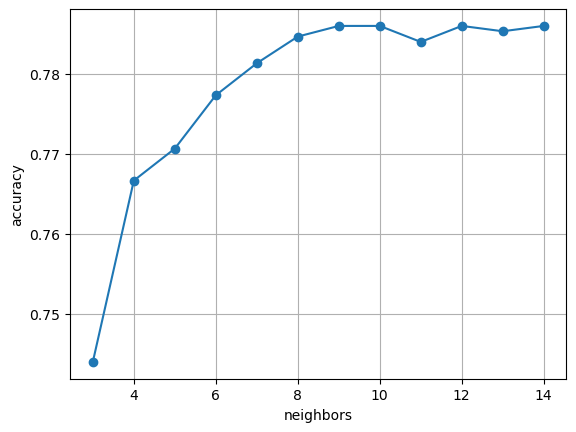

In [47]:
plt.plot(neighbors, metric_k,'o-')
plt.xlabel("neighbors")
plt.ylabel("accuracy")
plt.grid()
plt.show()

In [48]:
kn=KNeighborsClassifier(n_neighbors=9,metric="euclidean")
kn.fit(x_train,y_train)
y_predkn=kn.predict(x_test)
accuracykn=accuracy_score(y_test,y_predkn)
accuracykn

0.786

In [49]:
xgb=XGBClassifier()
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [50]:
y_predxgb=xgb.predict(x_test)
y_predxgb

array([0, 1, 0, ..., 0, 0, 0], shape=(1500,))

In [51]:
accuracyxgb=accuracy_score(y_test,y_predxgb)
accuracyxgb

0.766

In [52]:
cb=CatBoostClassifier()
cb.fit(x_train,y_train)

Learning rate set to 0.017589
0:	learn: 0.6833667	total: 153ms	remaining: 2m 33s
1:	learn: 0.6741396	total: 155ms	remaining: 1m 17s
2:	learn: 0.6651219	total: 158ms	remaining: 52.5s
3:	learn: 0.6562165	total: 160ms	remaining: 39.8s
4:	learn: 0.6482241	total: 162ms	remaining: 32.3s
5:	learn: 0.6403188	total: 164ms	remaining: 27.2s
6:	learn: 0.6325746	total: 167ms	remaining: 23.7s
7:	learn: 0.6252827	total: 169ms	remaining: 21s
8:	learn: 0.6184528	total: 171ms	remaining: 18.9s
9:	learn: 0.6116066	total: 174ms	remaining: 17.3s
10:	learn: 0.6051289	total: 177ms	remaining: 15.9s
11:	learn: 0.5987851	total: 179ms	remaining: 14.7s
12:	learn: 0.5925942	total: 182ms	remaining: 13.8s
13:	learn: 0.5867956	total: 184ms	remaining: 12.9s
14:	learn: 0.5812693	total: 186ms	remaining: 12.2s
15:	learn: 0.5759857	total: 188ms	remaining: 11.6s
16:	learn: 0.5704923	total: 190ms	remaining: 11s
17:	learn: 0.5654865	total: 192ms	remaining: 10.5s
18:	learn: 0.5605338	total: 194ms	remaining: 10s
19:	learn: 0.55

In [53]:
y_predcb=cb.predict(x_test)
y_predcb

array([0, 1, 0, ..., 0, 0, 0], shape=(1500,))

In [54]:
accuracycb=accuracy_score(y_test,y_predcb)
accuracycb

0.7913333333333333

In [55]:
lg=LGBMClassifier()
lg.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 774, number of negative: 2726
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1394
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221143 -> initscore=-1.259019
[LightGBM] [Info] Start training from score -1.259019


  File "c:\Users\tatak\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\tatak\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tatak\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tatak\anaconda3\Lib\subprocess.

LGBMClassifier()

In [56]:
y_predlg=lg.predict(x_test)
y_predlg

array([0, 1, 0, ..., 0, 0, 0], shape=(1500,))

In [57]:
accuracylg=accuracy_score(y_test,y_predlg)
accuracylg

0.7833333333333333

<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     TABLE
</h2>


In [58]:
from tabulate import tabulate
table=[["Model","Accuracy_score"],["LogisticRegression",accuracylr],
       ["GradientBoostingClassifier",accuracygb],["RandomForestClassifier",accuracyrf],
       ["DecisionTreeClassifier",accuracydt],["SVC linear",accuracysvlin],
       ["SVC non linear",accuracysvrbf],["KNeighborsClassifier",accuracykn],
       ["XGBClassifier",accuracyxgb],["CatBoostClassifier",accuracycb],
       ["LGBMClassifier",accuracylg]]
print(tabulate(table,headers="firstrow",tablefmt="fancy_grid"))

╒════════════════════════════╤══════════════════╕
│ Model                      │   Accuracy_score │
╞════════════════════════════╪══════════════════╡
│ LogisticRegression         │         0.789333 │
├────────────────────────────┼──────────────────┤
│ GradientBoostingClassifier │         0.795333 │
├────────────────────────────┼──────────────────┤
│ RandomForestClassifier     │         0.786    │
├────────────────────────────┼──────────────────┤
│ DecisionTreeClassifier     │         0.713333 │
├────────────────────────────┼──────────────────┤
│ SVC linear                 │         0.778    │
├────────────────────────────┼──────────────────┤
│ SVC non linear             │         0.787333 │
├────────────────────────────┼──────────────────┤
│ KNeighborsClassifier       │         0.786    │
├────────────────────────────┼──────────────────┤
│ XGBClassifier              │         0.766    │
├────────────────────────────┼──────────────────┤
│ CatBoostClassifier         │         0.791333 │


<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     MODEL TUNING
</h2>


In [59]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [60]:
model=GradientBoostingClassifier()

In [61]:
param_ran={ 'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 5, 6]}

In [62]:
random_search=RandomizedSearchCV(model,param_distributions=param_ran,n_iter=10,cv=5)
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 500]})

In [63]:
print("Best parameters:", random_search.best_params_)

Best parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01}


In [64]:
finalmodel=GradientBoostingClassifier(n_estimators=200,max_depth=5,learning_rate=0.01)
finalmodel.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200)

In [65]:
y_pred=finalmodel.predict(x_test)

In [66]:
finalaccuracy=accuracy_score(y_test,y_pred)
finalaccuracy

0.796

In [67]:
model1=GradientBoostingClassifier()

In [68]:
param_grid={ 'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 5, 6]}

In [69]:
Grid_search=GridSearchCV(model1,param_grid,cv=5)
Grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [100, 200, 500]})

In [70]:
print("Best parameters:", Grid_search.best_params_)

Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


In [71]:
finalmodel1=GradientBoostingClassifier(learning_rate=0.01,n_estimators=200,max_depth=3)
finalmodel1.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.01, n_estimators=200)

In [72]:
y_pred1=finalmodel1.predict(x_test)

In [73]:
finalaccuracy1=accuracy_score(y_test,y_pred1)
finalaccuracy1

0.7986666666666666

<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     METRICS
</h2>


In [74]:
from sklearn.metrics import precision_score,recall_score,f1_score,roc_curve,auc,classification_report,confusion_matrix

In [75]:
precision=precision_score(y_test,y_pred1)
precision

0.6165413533834586

In [76]:
recall=recall_score(y_test,y_pred1)
recall

0.24624624624624625

In [77]:
f1=f1_score(y_test,y_pred1)
f1

0.351931330472103

In [78]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred1)
roc_auc = auc(fpr, tpr)
print("\nROC AUC Score:", roc_auc)


ROC AUC Score: 0.6012722233801925


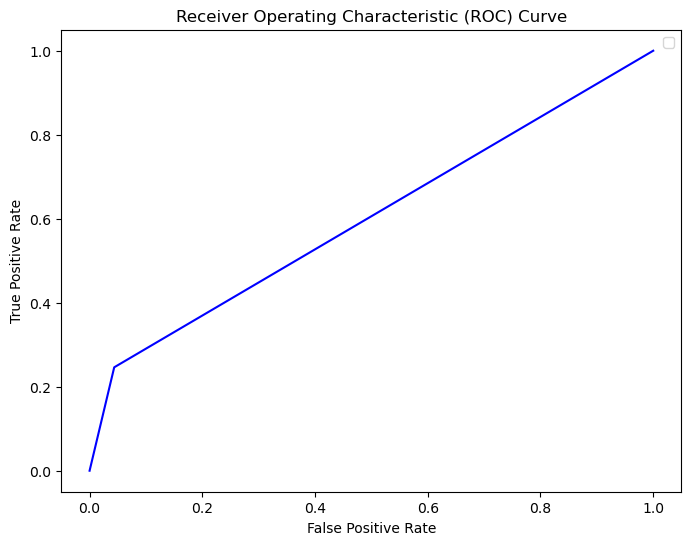

In [79]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue')
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [80]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88      1167
           1       0.62      0.25      0.35       333

    accuracy                           0.80      1500
   macro avg       0.72      0.60      0.62      1500
weighted avg       0.77      0.80      0.76      1500



In [81]:
cm=confusion_matrix(y_test, y_pred, labels=[0,1])
cm

array([[1114,   53],
       [ 253,   80]])

<h2 style="
background: linear-gradient(90deg, #10cde7);
color: white;
padding: 10px;
border-radius: 12px;
text-align:center;
font-weight:bold;
animation: slide 1s ease-out;">
     PREDICTION
</h2>


In [82]:
arr=x.iloc[0].tolist()
print(arr)

[-1.135821593311784, -0.8636029503573514, 1.0564158416335103, -1.1217646441622693, -1.238540998123216, 1.6877783708423524, 1.7780301157294063, -0.7469314009868342, -0.7868140244367481, -0.7993256218273719, -0.9958124950986226, -0.7280996316136967, -0.8625054306655868]


In [83]:
new_df=[[-1.135821593311784, -0.8636029503573514, 1.0564158416335103, -1.1217646441622693, -1.238540998123216, 1.6877783708423524, 1.7780301157294063, -0.7469314009868342, -0.7868140244367481, -0.7993256218273719, -0.9958124950986226, -0.7280996316136967, -0.8625054306655868]]

In [88]:
pickle.dump(finalmodel1, open("gbmodel.pkl","wb"))

In [ ]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'default payment next month'],
      dtype='object')